In [1]:
# 🛒 E-Commerce Data Analysis & Customer Segmentation
### Using Python, Pandas, Matplotlib & Scikit-learn


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
## 📂 1. Load Dataset

In [4]:
df = pd.read_csv(r"C:\Users\beesh\OneDrive\Desktop\E-Commerce\Dataset.csv", encoding="cp1252")
print("Rows:", len(df))
print("Columns:", len(df.columns))
df.head()

Rows: 541909
Columns: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
## 📊 2. Business Analysis

In [6]:
print("Top Countries:")
print(df["Country"].value_counts().head())

print("\nTop Products:")
print(df["Description"].value_counts().head(10))

Top Countries:
Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Name: count, dtype: int64

Top Products:
Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
ASSORTED COLOUR BIRD ORNAMENT         1501
SET OF 3 CAKE TINS PANTRY DESIGN      1473
PACK OF 72 RETROSPOT CAKE CASES       1385
LUNCH BAG  BLACK SKULL.               1350
NATURAL SLATE HEART CHALKBOARD        1280
Name: count, dtype: int64


In [7]:
## 💰 3. Revenue Analysis

In [8]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
print("Total Revenue:", df["Revenue"].sum())

print("\nRevenue by Country:")
print(df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10))

Total Revenue: 9747747.934

Revenue by Country:
Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Revenue, dtype: float64


In [9]:
## 🧹 4. Data Cleaning

In [10]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df.dropna(subset=["CustomerID"])
print("Clean data rows:", len(df))
print("Unique Customers:", df["CustomerID"].nunique())

Clean data rows: 397924
Unique Customers: 4339


In [11]:
## 📈 5. Visualizations

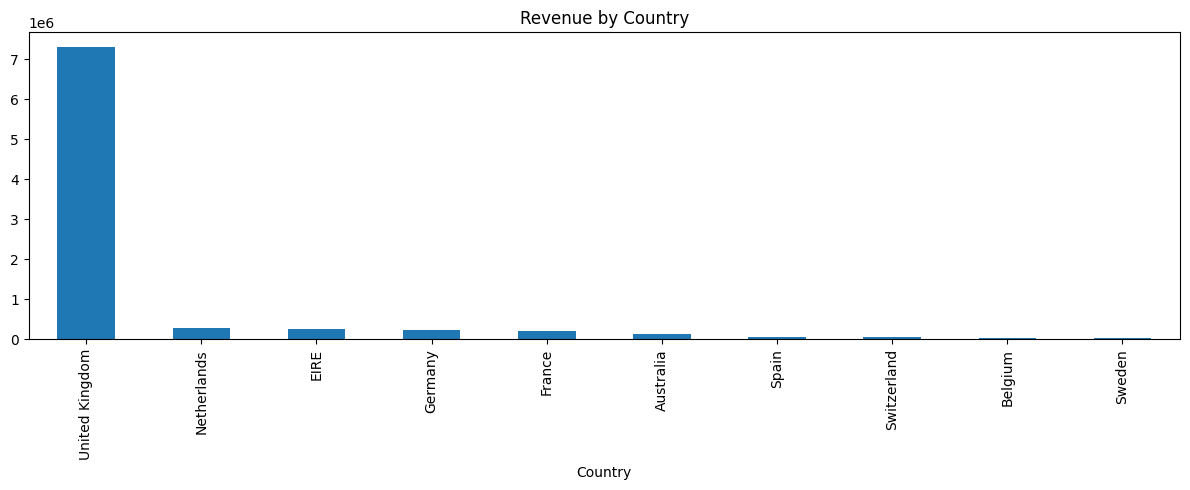

In [12]:
# Revenue by Country
df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10).plot(kind="bar", figsize=(12,5))
plt.title("Revenue by Country")
plt.tight_layout()
plt.savefig("revenue_by_country.png")
plt.show()

In [13]:
## 📅 6. Monthly Revenue Trend

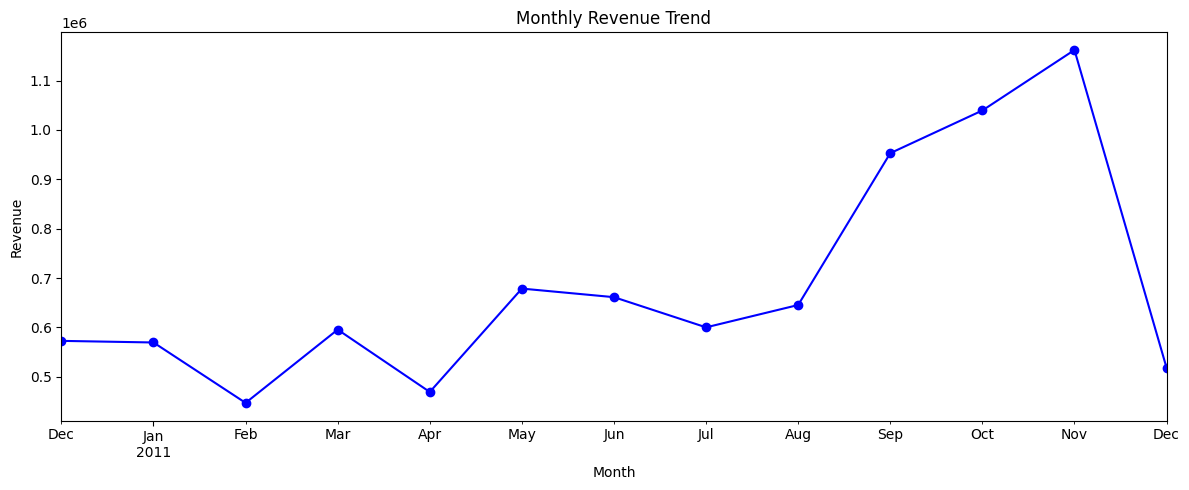

In [14]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Month"] = df["InvoiceDate"].dt.to_period("M")
monthly_revenue = df.groupby("Month")["Revenue"].sum()

monthly_revenue.plot(kind="line", figsize=(12,5), marker="o", color="blue")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("monthly_revenue.png")
plt.show()

In [15]:
## 🎯 7. RFM Analysis

In [16]:
snapshot_date = df["InvoiceDate"].max() + datetime.timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Revenue": "sum"
}).reset_index()

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]
rfm.to_csv("rfm_analysis.csv", index=False)
print("RFM Table:")
rfm.head(10)

RFM Table:


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
5,12352.0,36,8,2506.04
6,12353.0,204,1,89.00
7,12354.0,232,1,1079.40
8,12355.0,214,1,459.40
9,12356.0,23,3,2811.43


In [17]:
## 🤖 8. Machine Learning - Customer Segmentation

Customer Segments:
Segment_Label
Champions          3053
At Risk            1062
Lost Customers      211
Loyal Customers      13
Name: count, dtype: int64


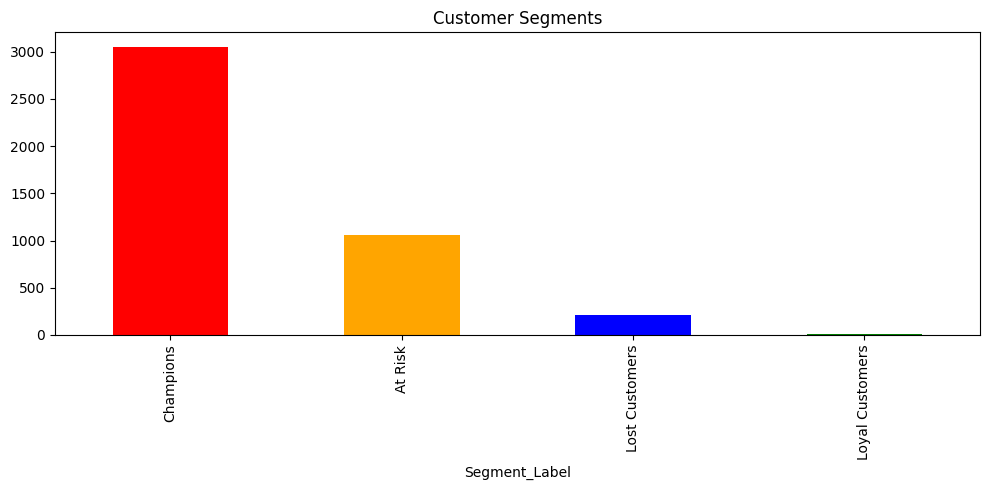

Saved ✅


In [18]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

kmeans = KMeans(n_clusters=4, random_state=42)
rfm["Segment"] = kmeans.fit_predict(rfm_scaled)

segment_labels = {0: "Lost Customers", 1: "At Risk", 2: "Loyal Customers", 3: "Champions"}
rfm["Segment_Label"] = rfm["Segment"].map(segment_labels)

print("Customer Segments:")
print(rfm["Segment_Label"].value_counts())

rfm["Segment_Label"].value_counts().plot(kind="bar", color=["red","orange","blue","green"], figsize=(10,5))
plt.title("Customer Segments")
plt.tight_layout()
plt.savefig("customer_segments.png")
plt.show()

rfm.to_csv("customer_segments.csv", index=False)
print("Saved ✅")

## ✅ Key Insights
- **UK** generates the highest revenue
- **November-December** are peak sales months
- **Champions** are high-value frequent buyers
- **At Risk** customers need re-engagement campaigns